In [7]:
%load_ext autoreload
%autoreload 2
import os
import glob
import h5py
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/preprocessing')
sys.path.append('../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid, verify_image_vector, verify_image_in_hdf5_file
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm
from custom_transform import ZoomTransform

device = torch.device('cuda:0')
model = torch.load('../../saved_models/05242024-benchmark-ResNet50-v5_10m/epoch-20.pt', map_location=device).module

import h5py

def calculate_uc_area(h5_file, group='test'):
    with h5py.File(h5_file, 'r') as f:
        va = np.array(f[group]['primitive_uc_vector_a'])
        vb = np.array(f[group]['primitive_uc_vector_b'])
        shapes = f[group]['shape']
        shape_dict = { 'rectangular': 0, 'square': 0, 'oblique': 1, 'hexagonal': 1, 'rhombic': 2, 'triangle': 3 }
        shape_dict_inv = {v: k for k, v in shape_dict.items()}  
        shapes = [shape_dict_inv[s] for s in shapes]

    areas = []
    for a, b, shape in zip(va, vb, shapes):
        if shape != 'triangle':
            areas.append(np.linalg.norm(np.cross(a, b)))
        else:
            areas.append(np.linalg.norm(np.cross(a, b)) / 2)
    return areas

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
areas_list = []
for file in ['../../datasets/symmetry_dataset/atom_v5_rot_200k.h5', '../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', 
             '../../datasets/symmetry_dataset/atom_v5_small_uc_600_200k.h5', '../../datasets/symmetry_dataset/atom_v5_small_uc_800_zoom960_200k.h5']:
    areas = calculate_uc_area(file)
    areas_list.append(areas)

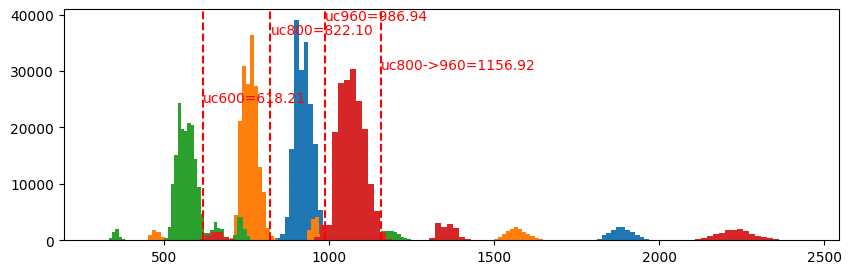

In [24]:
fig, axes = plt.subplots(1, 1, figsize=(10, 3))
for areas, k in zip(areas_list, ['960', '800', '600', '800->960']):
    n, bins, patches = axes.hist(areas, bins=100)
    axes.axvline(np.mean(areas), color='r', linestyle='--')
    axes.text(np.mean(areas), np.max(n), f'uc{k}={np.mean(areas):.2f}', color='r')
plt.show()

In [39]:
keywords = ['atom_v5_200k', 'atom_v5_small_uc_800_200k']
for k in keywords:
    file = glob.glob(f'../../saved_results/Dataset_benchmark/resnet50-{k}*.npy')[0]
    print(file)
    cm = np.load(file)
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    # plot_cm(cm, symmetry_classes, title=file.split('/')[-1].split('.')[0], cm_style='simple', fig_style='printing', font_size=4)

../../saved_results/Dataset_benchmark/resnet50-atom_v5_200k_cm.npy
Accuracy: 84.10%

../../saved_results/Dataset_benchmark/resnet50-atom_v5_small_uc_800_200k-zoomed_to_960_cm.npy
Accuracy: 50.25%



In [109]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# atom_v5_960_200k
atom_v5_200k_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_200k_dl = DataLoader(atom_v5_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_200k_dl, label_converter=label_converter, title='atom_v5_960_200k')

# atom_v5_small_uc_800_200k
atom_v5_small_uc_800_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_800_200k_dl = DataLoader(atom_v5_small_uc_800_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_800_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_200k')

In [ ]:
# atom_v5_small_uc_800_zoom_200k
zoom_range = (np.sqrt(960/800), np.sqrt(960/800))
transform = transforms.Compose([ZoomTransform(zoom_range=(np.sqrt(960/800), np.sqrt(960/800)), output_size=(256, 256)), transforms.ToTensor()])
atom_v5_small_uc_800_zoom_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', folder='test', transform=transform)
atom_v5_small_uc_800_zoom_200k_dl = DataLoader(atom_v5_small_uc_800_zoom_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_800_zoom_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_zoom_200k')

### create new dataset for verification

In [25]:
zoom_range = (np.sqrt(960/800), np.sqrt(960/800))
custom_transform = ZoomTransform(zoom_range=zoom_range, output_size=(256, 256))
with h5py.File('/mnt/d/datasets/symmetry_dataset/atom_v5_small_uc_800_zoom960_200k.h5', 'a') as h5:
    print(h5['test'].keys())
    for i in tqdm(range(len(h5['test']['data']))[5:]):
        img = h5['test']['data'][i]
        ts = h5['test']['translation_start_point'][i]
        va = h5['test']['primitive_uc_vector_a'][i]
        vb = h5['test']['primitive_uc_vector_b'][i]
        # print(img.shape, img.dtype, np.min(img), np.max(img))
        # print(ts, va, vb)
        # verify_image_vector(None, img, ts, va, vb)
                
        transformed_image, vectors = custom_transform(img, vectors=(ts, va, vb))
        # ts, va, vb = vectors
        # print(img.shape, img.dtype, np.min(img), np.max(img))
        # print(ts, va, vb)
        # verify_image_vector(None, transformed_image, ts, va, vb)

        h5['test']['data'][i] = transformed_image
        h5['test']['translation_start_point'][i] = vectors[0]
        h5['test']['primitive_uc_vector_a'][i] = vectors[1]
        h5['test']['primitive_uc_vector_b'][i] = vectors[2]

<KeysViewHDF5 ['data', 'labels', 'position_b', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'radius_a', 'radius_b', 'shape', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b']>


  0%|          | 0/203995 [00:00<?, ?it/s]

100%|██████████| 203995/203995 [36:18<00:00, 93.64it/s] 


In [26]:
areas_list = []
for file in ['../../datasets/symmetry_dataset/atom_v5_rot_200k.h5', '../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', 
             '../../datasets/symmetry_dataset/atom_v5_small_uc_600_200k.h5', '../../datasets/symmetry_dataset/atom_v5_small_uc_800_zoom960_200k.h5']:
    areas = calculate_uc_area(file)
    areas_list.append(areas)

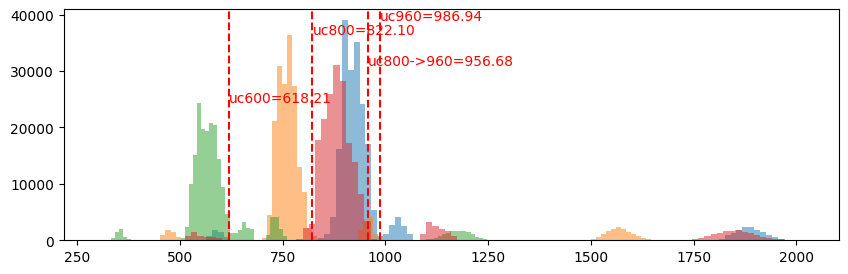

In [27]:
fig, axes = plt.subplots(1, 1, figsize=(10, 3))
for areas, k in zip(areas_list, ['960', '800', '600', '800->960']):
    n, bins, patches = axes.hist(areas, bins=100, alpha = 0.5)
    axes.axvline(np.mean(areas), color='r', linestyle='--')
    axes.text(np.mean(areas), np.max(n), f'uc{k}={np.mean(areas):.2f}', color='r')
plt.show()

In [37]:
zoom_range = (np.sqrt(986/822), np.sqrt(986/822))
custom_transform = ZoomTransform(zoom_range=zoom_range, output_size=(256, 256))
with h5py.File('/mnt/d/datasets/symmetry_dataset/atom_v5_small_uc_800_zoom960_2_200k.h5', 'a') as h5:
    print(h5['test'].keys())
    for i in tqdm(range(len(h5['test']['data']))[5:]):
        img = h5['test']['data'][i]
        ts = h5['test']['translation_start_point'][i]
        va = h5['test']['primitive_uc_vector_a'][i]
        vb = h5['test']['primitive_uc_vector_b'][i]
        # print(img.shape, img.dtype, np.min(img), np.max(img))
        # print(ts, va, vb)
        # verify_image_vector(None, img, ts, va, vb)
                
        transformed_image, vectors = custom_transform(img, vectors=(ts, va, vb))
        # ts, va, vb = vectors
        # print(img.shape, img.dtype, np.min(img), np.max(img))
        # print(ts, va, vb)
        # verify_image_vector(None, transformed_image, ts, va, vb)

        h5['test']['data'][i] = transformed_image
        h5['test']['translation_start_point'][i] = vectors[0]
        h5['test']['primitive_uc_vector_a'][i] = vectors[1]
        h5['test']['primitive_uc_vector_b'][i] = vectors[2]

<KeysViewHDF5 ['data', 'labels', 'position_b', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'radius_a', 'radius_b', 'shape', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b']>


100%|██████████| 203995/203995 [40:03<00:00, 84.87it/s] 


In [38]:
areas_list = []
for file in ['../../datasets/symmetry_dataset/atom_v5_rot_200k.h5', '../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', 
             '../../datasets/symmetry_dataset/atom_v5_small_uc_600_200k.h5', '../../datasets/symmetry_dataset/atom_v5_small_uc_800_zoom960_2_200k.h5']:
    areas = calculate_uc_area(file)
    areas_list.append(areas)

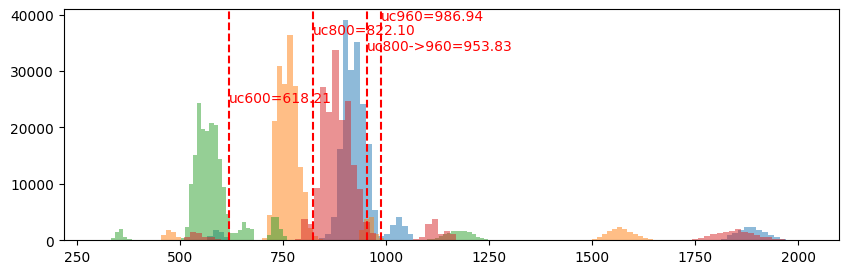

In [39]:
fig, axes = plt.subplots(1, 1, figsize=(10, 3))
for areas, k in zip(areas_list, ['960', '800', '600', '800->960']):
    n, bins, patches = axes.hist(areas, bins=100, alpha = 0.5)
    axes.axvline(np.mean(areas), color='r', linestyle='--')
    axes.text(np.mean(areas), np.max(n), f'uc{k}={np.mean(areas):.2f}', color='r')
plt.show()

### single record

In [14]:
image = imgs[0]
ts = ts_list[0]
va = va_list[0]
vb = vb_list[0]
verify_image_vector(None, image, ts, va, vb)

custom_transform = ZoomTransform(zoom_range=(1.2, 1.5), output_size=(256, 256))
transformed_image, vectors = custom_transform(image, vectors=(ts, va, vb))
ts, va, vb = vectors
verify_image_vector(None, transformed_image, ts, va, vb)

NameError: name 'imgs' is not defined

### manual 

In [91]:
imgs, labels_str, metadata = verify_image_in_hdf5_file('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', [0,1], group='test', viz=False)
ts_list, va_list, vb_list, VA_list, VB_list = metadata['ts'], metadata['va'], metadata['vb'], metadata['VA'], metadata['VB']

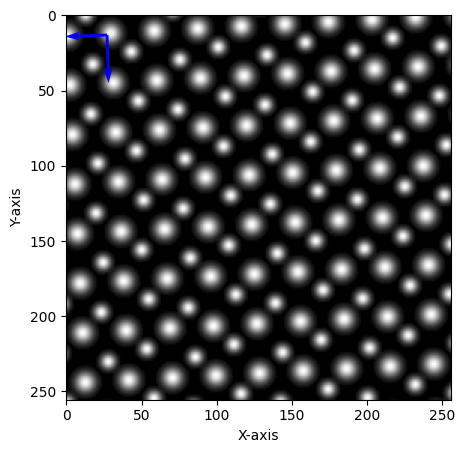

(array([13, 27], dtype=int32), array([32,  1], dtype=int32), array([  1, -28], dtype=int32)) 1.2630518050629032


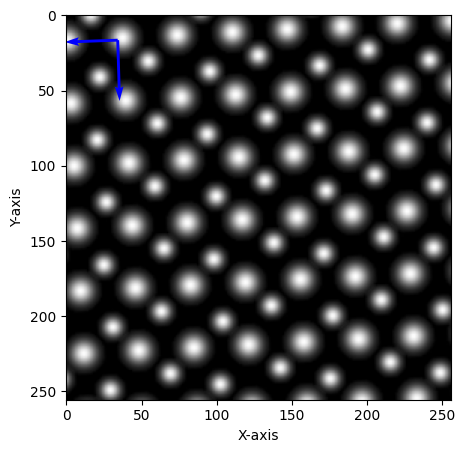

In [104]:
image = imgs[0]
ts = ts_list[0]
va = va_list[0]
vb = vb_list[0]
verify_image_vector(None, image, ts, va, vb)

custom_transform = ZoomTransform(zoom_range=(1.2, 1.5), output_size=(256, 256))
transformed_image, vectors = custom_transform(image, vectors=(ts, va, vb))
ts, va, vb = vectors
verify_image_vector(None, transformed_image, ts, va, vb)

In [11]:
img_800 = atom_v5_small_uc_800_200k_ds[0][0]

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
verify_image_vector(ax, img_800, )
img_960 = atom_v5_200k_ds[0][0]


In [30]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)


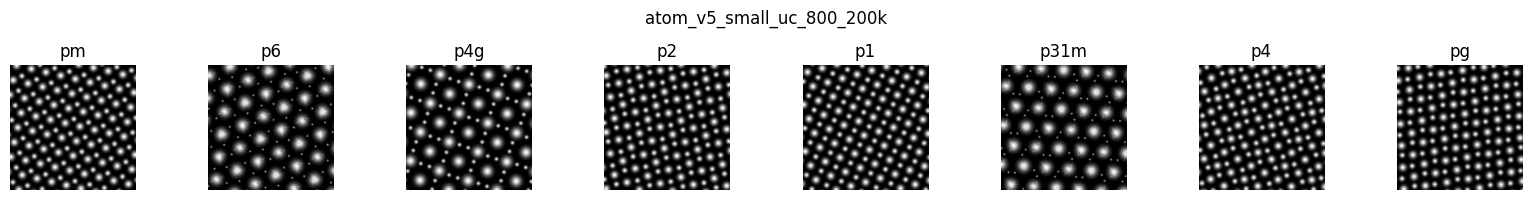

100%|██████████| 399/399 [05:59<00:00,  1.11it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0


Accuracy for these batches: 78.49509803921568%


In [32]:
# atom_v5_small_uc_800_200k
atom_v5_small_uc_800_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_800_zoom960_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_800_200k_dl = DataLoader(atom_v5_small_uc_800_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_800_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_200k')
plt.show()

name = 'atom_v5_small_uc_800_200k-zoomed_to_960'
cm = confusion_matrix(model, atom_v5_small_uc_800_200k_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../saved_results/Dataset_benchmark/resnet50-{name}_cm.npy', cm)

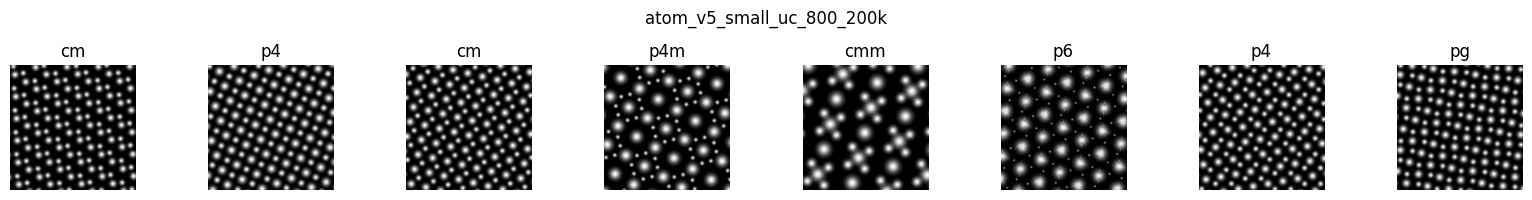

100%|██████████| 399/399 [34:39<00:00,  5.21s/it]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0


Accuracy for these batches: 78.49460784313726%


In [36]:
# atom_v5_small_uc_800_200k
zoom_range = (np.sqrt(960/800), np.sqrt(960/800))
transform = transforms.Compose([
    ZoomTransform(zoom_range=zoom_range, output_size=(256, 256)),
    # transforms.ToPILImage(), # Convert tensor back to PIL image (if needed for further transforms)
    transforms.ToTensor() # Convert PIL image back to tensor for model input
])

# atom_v5_small_uc_800_200k
atom_v5_small_uc_800_200k_ds = hdf5_dataset('../../datasets/symmetry_dataset/atom_v5_small_uc_800_200k.h5', folder='test', transform=transform)
atom_v5_small_uc_800_200k_dl = DataLoader(atom_v5_small_uc_800_200k_ds, batch_size=512, shuffle=True, num_workers=2)
viz_dataloader(atom_v5_small_uc_800_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_800_200k')
plt.show()

name = 'atom_v5_small_uc_800_200k-zoomed_to_960_transform'
cm = confusion_matrix(model, atom_v5_small_uc_800_200k_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../saved_results/Dataset_benchmark/resnet50-{name}_cm.npy', cm)